### train simple unet

This is the basic example of training a diffusion-based text to image Unet model

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import json
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers.models import AutoencoderKLFlux2
from diffusers import EulerDiscreteScheduler
from safetensors.torch import load_file
from torchvision import transforms
import torch
import time
import cv2

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

device = "cuda"

In [2]:
text_encoder = CLIPTextModel.from_pretrained("../stable-diffusion-xl-base-1.0/text_encoder").to("cuda", torch.float32)
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained("../stable-diffusion-xl-base-1.0/text_encoder_2").to("cuda", torch.float32)

tokenizer = CLIPTokenizer.from_pretrained("../stable-diffusion-xl-base-1.0/tokenizer")
tokenizer_2 = CLIPTokenizer.from_pretrained("../stable-diffusion-xl-base-1.0/tokenizer_2")

vae = AutoencoderKLFlux2.from_pretrained("../FLUX.2-klein-4B/vae", device=device).to(device)

scheduler = EulerDiscreteScheduler.from_pretrained("../stable-diffusion-xl-base-1.0/scheduler", timestep_spacing="trailing")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [3]:
def encode_text_batch_enc1(text_batch):
    inputs = tokenizer(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).to("cuda")
    
    with torch.no_grad():
        embed = text_encoder(inputs.input_ids, output_hidden_states=True, return_dict=True)
        text_embeds = embed.pooler_output

    return text_embeds

def encode_text_batch_enc2(text_batch):
    inputs_2 = tokenizer_2(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer_2.model_max_length,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        enc2 = text_encoder_2(
            inputs_2.input_ids,
            output_hidden_states=True,
            return_dict=True,
        )

    text_embeds = enc2.text_embeds

    return text_embeds

In [4]:
train_batch_size = 128
latent_std = 1.75

In [5]:
class LatentsAndEmbedsDataset(Dataset):
    def __init__(self):
        self.embeds = torch.load("../precomputes/embeds_enc1.pt")
        self.latents = torch.load("../precomputes/latents_256x256.pt")
        self.latents /= latent_std
        
    def __len__(self):
        assert len(self.latents) == len(self.embeds)
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.embeds[idx]

In [6]:
dataset = LatentsAndEmbedsDataset()

In [7]:
print(dataset.latents.shape, dataset.latents.dtype, dataset.latents.device)
print(dataset.embeds.shape, dataset.embeds.dtype, dataset.embeds.device)

torch.Size([591753, 32, 32, 32]) torch.float16 cpu
torch.Size([591753, 768]) torch.float16 cpu


In [8]:
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

torch.Size([128, 32, 32, 32]) cpu torch.float16 tensor(-7.4883, dtype=torch.float16) tensor(6.4648, dtype=torch.float16)
torch.Size([128, 768]) cpu torch.float16 tensor(-7.2578, dtype=torch.float16) tensor(9.1406, dtype=torch.float16)


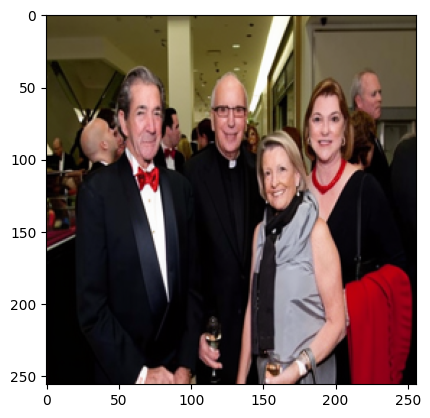

In [9]:
latents, embeds = next(iter(train_loader))
print(latents.shape, latents.device, latents.dtype, latents.min(), latents.max())
print(embeds.shape, embeds.device, embeds.dtype, embeds.min(), embeds.max())

with torch.no_grad():
    reconstructed = (vae.decode(latents[:1].cuda().float() * latent_std).sample + 1.0 ) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def make_group_norm(channels: int, max_groups: int = 32, eps: float = 1e-6) -> nn.GroupNorm:
    groups = min(max_groups, channels)
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, channels, eps=eps)


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        """
        timesteps: (B,)
        returns:   (B, dim)
        """
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device)) *
            torch.arange(half, device=timesteps.device, dtype=timesteps.dtype) / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ConditioningEncoder(nn.Module):
    """
    Fuses timestep and text into one conditioning vector.
    """
    def __init__(self, time_dim: int = 128, text_dim: int = 1280, cond_dim: int = 256):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        time_vec = self.time_proj(self.time_embed(timestep))
        text_vec = self.text_proj(text_embed)
        return time_vec + text_vec


class ConditionedResidualBlock(nn.Module):
    """
    SDXL-style residual block:
      GN -> SiLU -> Conv
      + condition (scale/shift)
      GN -> SiLU -> Dropout -> Conv
      + skip connection
    """
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.norm1 = make_group_norm(input_channels)
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1)

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 2 * output_channels),
        )

        self.norm2 = make_group_norm(output_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1)

        if input_channels != output_channels:
            self.skip = nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.cond_proj(cond)
        scale, shift = scale_shift.chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual


class DownBlock(nn.Module):
    def __init__(self, input_channels: int, output_channels: int, cond_dim: int = 256, dropout: float = 0.0):
        super().__init__()
        self.block = ConditionedResidualBlock(input_channels, output_channels, cond_dim=cond_dim, dropout=dropout)
        self.pool = nn.AvgPool2d(2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        x = self.block(x, cond)
        skip = x
        x = self.pool(x)
        return x, skip


class UpBlock(nn.Module):
    def __init__(self, base_channels: int, skip_channels: int, output_channels: int, cond_dim: int = 256, dropout: float = 0.0):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.block = ConditionedResidualBlock(
            base_channels + skip_channels,
            output_channels,
            cond_dim=cond_dim,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, skip: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        x = self.block(x, cond)
        return x


class UNet(nn.Module):
    def __init__(
        self,
        sample_channels: int = 32,
        base_channels: int = 64,
        text_dim: int = 768,
        time_dim: int = 128,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.conditioning = ConditioningEncoder(
            time_dim=time_dim,
            text_dim=text_dim,
            cond_dim=cond_dim,
        )

        self.in_conv = nn.Conv2d(sample_channels, base_channels, kernel_size=1, padding=0)

        self.enc1 = DownBlock(base_channels, base_channels, cond_dim=cond_dim, dropout=dropout)
        self.enc2 = DownBlock(base_channels, base_channels * 2, cond_dim=cond_dim, dropout=dropout)
        self.enc3 = ConditionedResidualBlock(base_channels * 2, base_channels * 4, cond_dim=cond_dim, dropout=dropout)

        self.dec1 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2, cond_dim=cond_dim, dropout=dropout)
        self.dec2 = UpBlock(base_channels * 2, base_channels, base_channels, cond_dim=cond_dim, dropout=dropout)

        self.out_conv = nn.Conv2d(base_channels, sample_channels, kernel_size=1, padding=0)

    def forward(self, sample: torch.Tensor, timestep: torch.Tensor, text_embed: torch.Tensor) -> torch.Tensor:
        cond = self.conditioning(timestep, text_embed)

        x = self.in_conv(sample)

        x, skip1 = self.enc1(x, cond)   # 64 -> 64, then downsample
        x, skip2 = self.enc2(x, cond)   # 64 -> 128, then downsample
        x = self.enc3(x, cond)          # 128 -> 256

        x = self.dec1(x, skip2, cond)   # 256 + 128 -> 128
        x = self.dec2(x, skip1, cond)   # 128 + 64  -> 64

        x = self.out_conv(x)
        return x

In [11]:
unet = UNet()
unet = unet.to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

In [12]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

alpha_bar = alpha_bar.to(device)

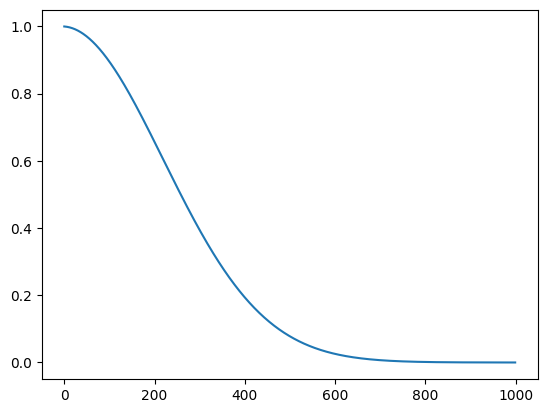

In [13]:
plt.plot(alpha_bar.cpu())
plt.show()

In [14]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output


def _get_next_sample_index(save_directory):
    """
    Finds the next available integer index for sample files
    of the form sample_<index>.png or sample_epochX_<index>.png.
    """
    pattern = re.compile(r"sample_(?:epoch\d+_)?(\d+)\.png")
    max_index = -1

    for fname in os.listdir(save_directory):
        match = pattern.match(fname)
        if match:
            max_index = max(max_index, int(match.group(1)))

    return max_index + 1


def generate_test_sample(save_directory="../samples/7.train-simple-unet", epoch_number=None, prompt = "A black dog on the green grass.", cfg = 7.0, save=True):
    os.makedirs(save_directory, exist_ok=True)

    sample_index = _get_next_sample_index(save_directory)

    if epoch_number is not None:
        filename = f"sample_epoch{epoch_number}_{sample_index}.png"
    else:
        filename = f"sample_{sample_index}.png"

    save_path = os.path.join(save_directory, filename)

    text_embed = encode_text_batch_enc1([prompt])
    negative_text_embed = torch.zeros_like(text_embed)
    

    scheduler.set_timesteps(50)
    latents = torch.normal(0, 1, (1, 32, 32, 32), dtype=torch.float32, device="cuda")
    latents = latents * scheduler.init_noise_sigma

    unet.eval()

    with torch.no_grad():
        for t in scheduler.timesteps:
            latent_model_input = scheduler.scale_model_input(latents, t)
            t = t.to(device).view(1)
            predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=text_embed)
            negative_predicted_noise = unet(sample=latent_model_input, timestep=t, text_embed=negative_text_embed)

            predicted_noise_cfg = negative_predicted_noise + (predicted_noise - negative_predicted_noise) * cfg
            
            latents = scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    with torch.no_grad():
        image = (vae.decode(latents * latent_std).sample + 1.0) / 2.0

    image = image.squeeze(0).permute((1, 2, 0)).float().cpu().numpy()
    image = np.clip(image, 0, 1)

    clear_output(wait=True)
    if save:
        plt.imsave(save_path, image)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

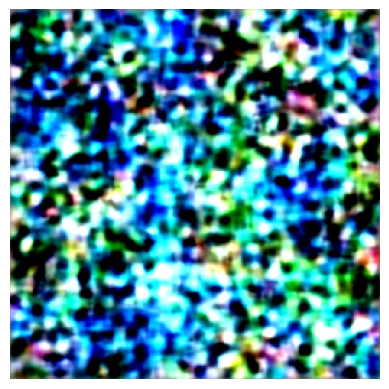

In [15]:
generate_test_sample(cfg=7)

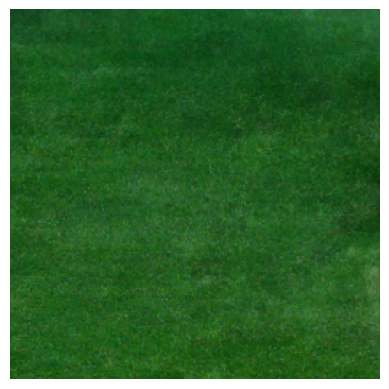

 47%|████▋     | 2156/4624 [00:45<00:51, 47.86it/s]


KeyboardInterrupt: 

In [16]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="../runs/train-simple-unet-2")

epochs = 1000

for epoch in range(epochs):
    num_steps = 0
    loss_sum = 0
    unet.train()
    for latents, text_embeds in tqdm(train_loader):
        num_steps += 1
        batch_size = latents.shape[0]
        latents = latents.cuda().float()
        text_embeds = text_embeds.cuda().float()
        embed_mask = torch.randint(0, 100, (batch_size, 1), device=device) > 5
        embed_mask = embed_mask.float()
        embed_mask = embed_mask.repeat(1, text_embeds.shape[1])
        text_embeds = text_embeds * embed_mask

        timesteps = torch.randint(0, T, (batch_size,), device=device)
        noise = torch.normal(0, 1, latents.shape, device=device)
        alpha_bar_t = alpha_bar[timesteps]
        alpha_bar_t = alpha_bar_t.view(batch_size, 1, 1, 1)
        
        noisy_latents = torch.sqrt(alpha_bar_t) * latents + torch.sqrt(1 - alpha_bar_t) * noise

        predicted_noise = unet(sample=noisy_latents, timestep=timesteps, text_embed=text_embeds)

        loss = ((noise - predicted_noise)**2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += float(loss.item())

    writer.add_scalar("train_loss", loss_sum / num_steps, epoch)
    generate_test_sample(epoch_number=epoch)

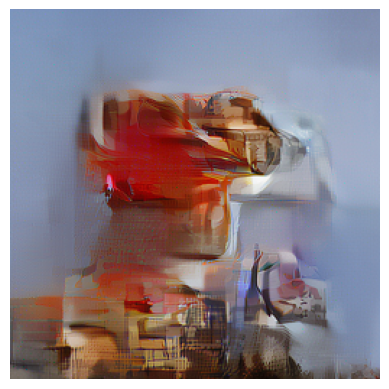

In [57]:
generate_test_sample(prompt="A red stop sign.", cfg=11)

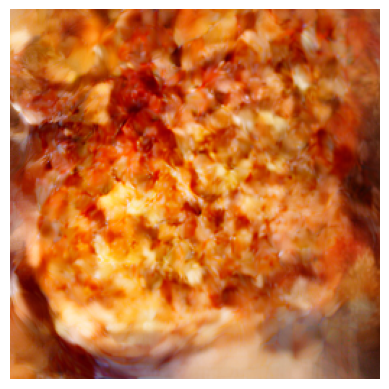

In [53]:
generate_test_sample(prompt="A pizza on a plate.", cfg=11)

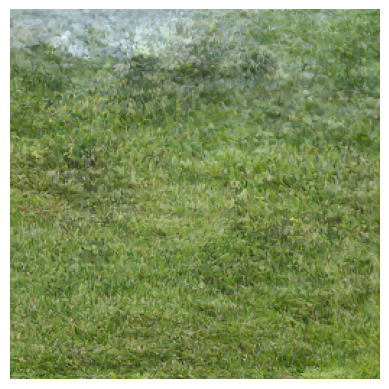

In [56]:
generate_test_sample(prompt="A black dog on the green grass.", cfg=11)

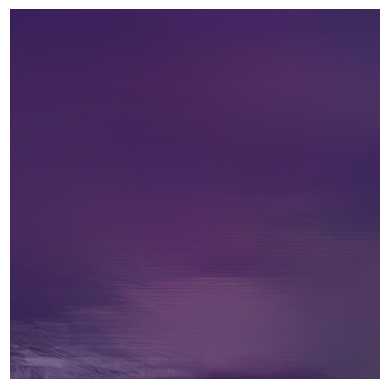

In [64]:
generate_test_sample(prompt="Violet sunset over the mountains.", cfg=11)